# Notebook 5 — RA Classification: CNN Training and Evaluation

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Rheumatoid Arthritis (RA) — Image Classification  
**Model:** ResNet-18 fine-tuned for RA vs Non-RA classification  

---

## Overview

This notebook trains a ResNet-18 CNN to classify hand X-ray images as **RA** (Rheumatoid Arthritis) or **Non-RA**.

**Prerequisites:** Run Notebooks 01–04 first to generate the manifest CSVs in `outputs/reports/`.

### What this notebook does, step by step:
1. Set up paths and random seed for reproducibility  
2. Load the train/val/test manifests  
3. Inspect class distribution and flag patient-leakage risk  
4. Define image augmentation transforms  
5. Build PyTorch Datasets and DataLoaders  
6. Handle the severe 14:1 class imbalance with weighted loss  
7. Build the ResNet-18 model  
8. Run the training loop (with early stopping and checkpointing)  
9. Plot training history  
10. Evaluate the best model on the test set  
11. Save all metrics, plots, and the model checkpoint  

---
> **Note on training time:** This machine has no GPU (CPU only). Training 20 epochs on 793 images takes approximately 30–90 minutes on CPU depending on hardware. The smoke-test section at the end runs only 2 mini-batches and completes in seconds.

---
## Section 1 — Project Setup

In [1]:
# Add FYP/ to sys.path so Python can find the src/ package.
# This is needed because the notebook lives in FYP/notebooks/
# and the modules live in FYP/src/.
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()   # one level up from notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('sys.path[0] :', sys.path[0])

PROJECT_ROOT: C:\Users\varsh\OneDrive\Documents\FYP
sys.path[0] : C:\Users\varsh\OneDrive\Documents\FYP


---
## Section 2 — Imports

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── Our custom modules (from src/) ────────────────────────────────────────────
from src.utils    import (set_seed, get_device, load_norm_stats,
                          check_patient_leakage, MetricsLogger,
                          TRAIN_CSV, VAL_CSV, TEST_CSV,
                          REPORTS_DIR, PLOTS_DIR, MODELS_DIR, BEST_MODEL,
                          CLASS_NAMES, IMG_SIZE)
from src.dataset  import RADataset, get_transforms
from src.model    import build_model
from src.train    import train, compute_class_weights
from src.evaluate import evaluate, plot_training_history

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

print('All imports OK.')
print(f'PyTorch version  : {torch.__version__}')
print(f'CUDA available   : {torch.cuda.is_available()}')

All imports OK.
PyTorch version  : 2.14.0+cpu
CUDA available   : False


---
## Section 3 — Configuration

All hyperparameters are defined in one place so they are easy to find and change.

In [3]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CONFIG = {
    # Image
    'img_size'        : (224, 224),   # resize target for ResNet-18

    # Training
    'batch_size'      : 16,           # number of images per batch
    'num_epochs'      : 20,           # maximum epochs (early stopping may end sooner)
    'learning_rate'   : 1e-4,         # initial learning rate for Adam
    'weight_decay'    : 1e-4,         # L2 regularisation strength
    'patience'        : 7,            # early stopping patience

    # Model
    'pretrained'      : True,         # use ImageNet weights (strongly recommended)
    'freeze_backbone' : False,        # train all layers (fine-tuning)
    'mode'            : 'image_only', # 'image_only' or 'multimodal'
    'dropout_rate'    : 0.5,

    # Reproducibility
    'seed'            : 42,

    # DataLoader
    'num_workers'     : 0,   # set to 0 on Windows to avoid multiprocessing issues
}

print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:<20} = {v}')

Configuration:
  img_size             = (224, 224)
  batch_size           = 16
  num_epochs           = 20
  learning_rate        = 0.0001
  weight_decay         = 0.0001
  patience             = 7
  pretrained           = True
  freeze_backbone      = False
  mode                 = image_only
  dropout_rate         = 0.5
  seed                 = 42
  num_workers          = 0


---
## Section 4 — Random Seed

In [4]:
# Fix the random seed for reproducibility.
# This seeds Python, NumPy, and PyTorch (both CPU and GPU).
set_seed(CONFIG['seed'])
print(f'Random seed set to {CONFIG["seed"]}.')

Random seed set to 42.


---
## Section 5 — Load Manifests

In [5]:
# Load the split manifests produced by Notebook 04.
# Each manifest has one row per image and includes:
#   full_path, isRA, age_norm, pixel_spacing, Sex_enc, laterality_enc, LR_enc

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train : {len(train_df)} images')
print(f'Val   : {len(val_df)} images')
print(f'Test  : {len(test_df)} images')
print(f'Total : {len(train_df) + len(val_df) + len(test_df)} images')

Train : 793 images
Val   : 140 images
Test  : 267 images
Total : 1200 images


---
## Section 6 — Inspect Class Distribution

In [6]:
# ── Class distribution per split ──────────────────────────────────────────────
label_map = {0: 'Non-RA', 1: 'RA'}

print('Class distribution:')
print(f'{"Split":<8} {"Non-RA":>8} {"RA":>8} {"Total":>8} {"RA%":>8}')
print('-' * 45)
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    nra = int((df['isRA'] == 0).sum())
    ra  = int((df['isRA'] == 1).sum())
    tot = nra + ra
    pct = ra / tot * 100
    print(f'{name:<8} {nra:>8} {ra:>8} {tot:>8} {pct:>7.1f}%')
print()
print('IMPORTANT: ~93% of images are RA — this is severe class imbalance.')
print('A naive model predicting RA for every image would get 93% accuracy')
print('but would be clinically useless. We address this with weighted loss.')

Class distribution:
Split      Non-RA       RA    Total      RA%
---------------------------------------------
Train          74      719      793    90.7%
Val             4      136      140    97.1%
Test            2      265      267    99.3%

IMPORTANT: ~93% of images are RA — this is severe class imbalance.
A naive model predicting RA for every image would get 93% accuracy
but would be clinically useless. We address this with weighted loss.


In [7]:
# ── Patient leakage check ──────────────────────────────────────────────────────
# 17 patients appear in more than one split (found in Notebook 01).
# We report this explicitly and preserve the original split.

leakage_info = check_patient_leakage(train_df, val_df, test_df)

PATIENT LEAKAGE CHECK
  Train patients : 99
  Val   patients : 36
  Test  patients : 100

  Train ∩ Val  overlap : 6 patients
  Train ∩ Test overlap : 10 patients
  Val   ∩ Test overlap : 1 patients

  Patient IDs: [np.int64(4), np.int64(7), np.int64(29), np.int64(43), np.int64(46), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]

  EXPLANATION: The original dataset split from the authors is
  preserved as-is for reproducibility. This means a small number
  of patients have exams in multiple splits. This can cause
  'patient-level leakage': the model may have seen the same patient
  at a different time point during training, making test performance
  slightly optimistic.

  RECOMMENDATION: For rigorous evaluation, re-split using a strict
  patient-stratified GroupShuffleSplit. See the OPTIONAL section
  at the end of Notebook 05 for a ready-to-use example.


---
## Section 7 — Define Image Transforms

In [8]:
# Load the per-channel mean and std computed from training images in Notebook 04.
# These are used to standardise every image before it enters the network.
mean, std = load_norm_stats()
print(f'Channel mean : {mean}')
print(f'Channel std  : {std}')
print()

# Training: augmented transforms
# Validation and test: deterministic (no augmentation)
train_transform = get_transforms('train', CONFIG['img_size'], mean, std)
val_transform   = get_transforms('val',   CONFIG['img_size'], mean, std)
test_transform  = get_transforms('test',  CONFIG['img_size'], mean, std)

print('Training transforms (augmented):')
print(train_transform)
print()
print('Val/Test transforms (deterministic):')
print(val_transform)

Channel mean : [0.2503633202338705, 0.2503633202338705, 0.2503633202338705]
Channel std  : [0.2531105167199891, 0.2531105167199891, 0.2531105167199891]

Training transforms (augmented):
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.2503633202338705, 0.2503633202338705, 0.2503633202338705], std=[0.2531105167199891, 0.2531105167199891, 0.2531105167199891])
)

Val/Test transforms (deterministic):
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.2503633202338705, 0.2503633202338705, 0.2503633202338705], std=[0.2531105167199891, 0.2531105167199891, 0.2531105167199891])

---
## Section 8 — Define PyTorch Dataset

In [9]:
# Create Dataset objects.
# Each Dataset reads images on-the-fly from disk when __getitem__ is called.
# The original BMP files are NOT modified.

train_dataset = RADataset(TRAIN_CSV, transform=train_transform)
val_dataset   = RADataset(VAL_CSV,   transform=val_transform)
test_dataset  = RADataset(TEST_CSV,  transform=test_transform)

print()
print(f'Train dataset size : {len(train_dataset)}')
print(f'Val   dataset size : {len(val_dataset)}')
print(f'Test  dataset size : {len(test_dataset)}')
print()

# Verify one sample loads correctly
sample_img, sample_meta, sample_label = train_dataset[0]
print(f'Sample image tensor shape : {sample_img.shape}   (should be [3, 224, 224])')
print(f'Sample meta tensor shape  : {sample_meta.shape}  (5 metadata features)')
print(f'Sample label              : {sample_label.item()}  (0=Non-RA, 1=RA)')

[RADataset] Loaded 793 images from train_manifest.csv
[RADataset] Class distribution: Non-RA=74  RA=719
[RADataset] Loaded 140 images from val_manifest.csv
[RADataset] Class distribution: Non-RA=4  RA=136
[RADataset] Loaded 267 images from test_manifest.csv
[RADataset] Class distribution: Non-RA=2  RA=265

Train dataset size : 793
Val   dataset size : 140
Test  dataset size : 267

Sample image tensor shape : torch.Size([3, 224, 224])   (should be [3, 224, 224])
Sample meta tensor shape  : torch.Size([5])  (5 metadata features)
Sample label              : 0  (0=Non-RA, 1=RA)


---
## Section 9 — Create DataLoaders

In [10]:
# DataLoaders wrap Datasets and handle batching, shuffling, and parallel loading.

# We shuffle training data to prevent the model from learning the order of samples.
# Validation and test data are NOT shuffled (order doesn't matter for evaluation,
# and deterministic order makes debugging easier).

train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG['batch_size'],
    shuffle     = True,
    num_workers = CONFIG['num_workers'],
    pin_memory  = False,   # pin_memory=True only helps when CUDA is available
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG['batch_size'],
    shuffle     = False,
    num_workers = CONFIG['num_workers'],
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = CONFIG['batch_size'],
    shuffle     = False,
    num_workers = CONFIG['num_workers'],
)

print(f'Train loader : {len(train_loader)} batches of {CONFIG["batch_size"]}')
print(f'Val   loader : {len(val_loader)} batches')
print(f'Test  loader : {len(test_loader)} batches')

Train loader : 50 batches of 16
Val   loader : 9 batches
Test  loader : 17 batches


---
## Section 10 — Handle Class Imbalance

With 1120 RA and only 80 Non-RA images (14:1 ratio), a standard CrossEntropyLoss would cause the model to almost always predict RA, since that minimises loss on the majority class.

**Our solution: class-weighted CrossEntropyLoss**  
We assign a higher loss weight to Non-RA samples so errors on the minority class are penalised more strongly. The weight for each class is computed as:  
`weight[c] = total / (num_classes × count[c])`

In [11]:
device = get_device()

# Get class counts from the training set
class_counts = train_dataset.get_class_counts()
print(f'Training class counts: {class_counts}')
print()

# Compute inverse-frequency weights
class_weights = compute_class_weights(class_counts, device)
print()
print('These weights mean: an error on a Non-RA sample costs ~10x more than')
print('an error on an RA sample, forcing the model to pay attention to both classes.')

[utils] Using device: cpu
Training class counts: {1: 719, 0: 74}

[train] Class weights for CrossEntropyLoss:
  class 0 (Non-RA): count=  74  weight=5.3581
  class 1 (RA): count= 719  weight=0.5515

These weights mean: an error on a Non-RA sample costs ~10x more than
an error on an RA sample, forcing the model to pay attention to both classes.


---
## Section 11 — Define CNN Model

In [12]:
# Build the ResNet-18 model.
# pretrained=True loads ImageNet weights — the network has already learned
# low-level visual features from millions of natural images.
# We then fine-tune it on our X-ray images.

model = build_model(
    mode            = CONFIG['mode'],
    pretrained      = CONFIG['pretrained'],
    freeze_backbone = CONFIG['freeze_backbone'],
    dropout_rate    = CONFIG['dropout_rate'],
    device          = device,
)

print()
print('Model architecture summary:')
print(f'  Input shape  : (batch, 3, 224, 224)')
print(f'  Output shape : (batch, 2)  — logits for [Non-RA, RA]')
print(f'  Mode         : {CONFIG["mode"]}')
print(f'  GradCAM hook : model.backbone.layer4  (last conv block)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\varsh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.49MB/s]

[model] RAClassifier created
[model]   mode            = image_only
[model]   pretrained      = True
[model]   freeze_backbone = False
[model]   num_classes     = 2
[model] Total parameters    : 11,177,538
[model] Trainable parameters: 11,177,538
[model] Moved to device     : cpu

Model architecture summary:
  Input shape  : (batch, 3, 224, 224)
  Output shape : (batch, 2)  — logits for [Non-RA, RA]
  Mode         : image_only
  GradCAM hook : model.backbone.layer4  (last conv block)


---
## Section 12 — Define Loss Function and Optimiser

In [13]:
# ── Loss function: weighted CrossEntropyLoss ───────────────────────────────────
# CrossEntropyLoss is the standard choice for classification.
# The `weight` argument applies our class weights so minority-class
# errors contribute more to the total loss.
criterion = nn.CrossEntropyLoss(weight=class_weights)
print('Loss function: CrossEntropyLoss with class weights')
print(f'  Weight tensor: {class_weights.tolist()}')
print()

# ── Optimiser: Adam ────────────────────────────────────────────────────────────
# Adam adapts the learning rate individually for each parameter.
# It generally converges faster than SGD for fine-tuning tasks.
# weight_decay adds L2 regularisation to prevent overfitting.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = CONFIG['learning_rate'],
    weight_decay = CONFIG['weight_decay'],
)
print(f'Optimiser: Adam  lr={CONFIG["learning_rate"]}  weight_decay={CONFIG["weight_decay"]}')
print()

# ── Learning rate scheduler: ReduceLROnPlateau ─────────────────────────────────
# If validation loss stops improving for 3 epochs, reduce LR by factor of 0.5.
# This helps squeeze out final performance after the initial learning phase.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',    # reduce when the monitored metric stops decreasing
    factor   = 0.5,      # multiply LR by 0.5
    patience = 3,        # wait 3 epochs before reducing
)
print('LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)')

Loss function: CrossEntropyLoss with class weights
  Weight tensor: [5.358108043670654, 0.5514603853225708]

Optimiser: Adam  lr=0.0001  weight_decay=0.0001

LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


---
## Section 13 — Training Loop

The training loop runs for up to `num_epochs` epochs. Each epoch:
1. Runs a full pass over the training data (forward + backward + weight update)
2. Runs a full pass over the validation data (forward only, no update)
3. Logs train loss, val loss, train accuracy, val accuracy
4. Saves the model if validation loss improved (best-model checkpointing)
5. Checks the early-stopping counter

**Expected time on CPU:** ~2–4 minutes per epoch × 20 epochs ≈ 40–80 minutes total.

In [14]:
# Run the full training loop.
# This cell may take a long time on CPU. The model is checkpointed automatically
# whenever validation loss improves, so you can interrupt and resume safely.

# NOTE: If you only want to run the smoke test below without full training,
#       skip this cell and run Section 13b (Smoke Test) instead.

logger = train(
    model            = model,
    train_loader     = train_loader,
    val_loader       = val_loader,
    criterion        = criterion,
    optimizer        = optimizer,
    device           = device,
    num_epochs       = CONFIG['num_epochs'],
    patience         = CONFIG['patience'],
    mode             = CONFIG['mode'],
    checkpoint_path  = BEST_MODEL,
    scheduler        = scheduler,
)

Training for up to 20 epochs  |  patience=7
Best model → C:\Users\varsh\OneDrive\Documents\FYP\models\ra_resnet18_best.pth
  [log] epoch=1  |  train_loss=0.4328  |  val_loss=0.4002  |  train_acc=0.7831  |  val_acc=0.8929  |  lr=0.0001
  [checkpoint] New best val_loss=0.4002 — model saved.
  [log] epoch=2  |  train_loss=0.3315  |  val_loss=0.7852  |  train_acc=0.8701  |  val_acc=0.7000  |  lr=0.0001
  [log] epoch=3  |  train_loss=0.2957  |  val_loss=0.7271  |  train_acc=0.8878  |  val_acc=0.6786  |  lr=0.0001
  [log] epoch=4  |  train_loss=0.2564  |  val_loss=0.6799  |  train_acc=0.8979  |  val_acc=0.8571  |  lr=0.0001
  [log] epoch=5  |  train_loss=0.2038  |  val_loss=0.7667  |  train_acc=0.9142  |  val_acc=0.8500  |  lr=0.0001
  [log] epoch=6  |  train_loss=0.1879  |  val_loss=0.8180  |  train_acc=0.9256  |  val_acc=0.6286  |  lr=0.0001
  [log] epoch=7  |  train_loss=0.1559  |  val_loss=0.6620  |  train_acc=0.9357  |  val_acc=0.8071  |  lr=0.0001
  [log] epoch=8  |  train_loss=0.1485 

---
## Section 13b — Smoke Test (Quick Validation — 2 Batches Only)

Run this cell **instead of Section 13** if you only want to verify the pipeline works without waiting for full training.

This runs exactly 2 mini-batches of training and 2 of validation — enough to confirm every component works end-to-end.

In [15]:
# ── SMOKE TEST: 2 batches only ────────────────────────────────────────────────
# This is a controlled test, not full training.
# It does NOT produce a usable model.

SMOKE_TEST_BATCHES = 2

print(f'Running smoke test: {SMOKE_TEST_BATCHES} batches each of train and val...')
print()

model.train()
smoke_train_loss = 0.0
smoke_correct    = 0
smoke_total      = 0

for batch_idx, (images, meta, labels) in enumerate(train_loader):
    if batch_idx >= SMOKE_TEST_BATCHES:
        break
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    logits = model(images)
    loss   = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    smoke_train_loss += loss.item()
    smoke_correct    += (logits.argmax(1) == labels).sum().item()
    smoke_total      += labels.size(0)
    print(f'  Train batch {batch_idx+1}: loss={loss.item():.4f}  '
          f'labels={labels.tolist()}')

print()
model.eval()
with torch.no_grad():
    for batch_idx, (images, meta, labels) in enumerate(val_loader):
        if batch_idx >= SMOKE_TEST_BATCHES:
            break
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        print(f'  Val   batch {batch_idx+1}: loss={loss.item():.4f}  '
              f'labels={labels.tolist()}')

print()
print('Smoke test PASSED — pipeline works end-to-end.')
print('Run Section 13 for full training.')

Running smoke test: 2 batches each of train and val...

  Train batch 1: loss=0.1453  labels=[1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
  Train batch 2: loss=0.0933  labels=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]

  Val   batch 1: loss=2.3122  labels=[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Val   batch 2: loss=1.7550  labels=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Smoke test PASSED — pipeline works end-to-end.
Run Section 13 for full training.


---
## Section 14 — Validation Loop

The validation loop is already integrated inside `train()` from Section 13.  
This section manually runs one validation pass to inspect the raw output after training.

In [16]:
# Re-run validation after training to see final validation performance.
# This uses the current model weights (not necessarily the best checkpoint).

from src.train import validate_one_epoch

val_loss, val_acc = validate_one_epoch(
    model, val_loader, criterion, device, CONFIG['mode']
)

print(f'Final validation loss     : {val_loss:.4f}')
print(f'Final validation accuracy : {val_acc:.4f}')
print()
print('NOTE: The best model (lowest val_loss) is saved at:')
print(f'  {BEST_MODEL}')

Final validation loss     : 0.6874
Final validation accuracy : 0.7929

NOTE: The best model (lowest val_loss) is saved at:
  C:\Users\varsh\OneDrive\Documents\FYP\models\ra_resnet18_best.pth


---
## Section 15 — Save Best Model

The best model was already saved automatically during training whenever validation loss improved.  
This section confirms the checkpoint exists and shows its contents.

In [17]:
import os

if BEST_MODEL.exists():
    size_mb = os.path.getsize(BEST_MODEL) / (1024 * 1024)
    ckpt    = torch.load(BEST_MODEL, map_location='cpu', weights_only=True)
    print(f'Best model checkpoint found: {BEST_MODEL}')
    print(f'File size     : {size_mb:.2f} MB')
    print(f'Saved at epoch: {ckpt["epoch"]}')
    print(f'Val loss      : {ckpt["val_loss"]:.4f}')
    print(f'Val accuracy  : {ckpt["val_acc"]:.4f}')
else:
    print(f'WARNING: No checkpoint found at {BEST_MODEL}.')
    print('Run Section 13 (full training) to generate the best model checkpoint.')

Best model checkpoint found: C:\Users\varsh\OneDrive\Documents\FYP\models\ra_resnet18_best.pth
File size     : 42.72 MB
Saved at epoch: 1
Val loss      : 0.4002
Val accuracy  : 0.8929


---
## Section 16 — Plot Training History

In [18]:
from src.evaluate import plot_training_history

# This reads training_history.csv and saves four separate plots:
#   training_loss.png, validation_loss.png,
#   training_accuracy.png, validation_accuracy.png
# plus a combined overview.
plot_training_history()

[evaluate] Plot saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\training_loss.png
[evaluate] Plot saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\validation_loss.png
[evaluate] Plot saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\training_accuracy.png
[evaluate] Plot saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\validation_accuracy.png
[evaluate] Combined history plot → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\training_history.png


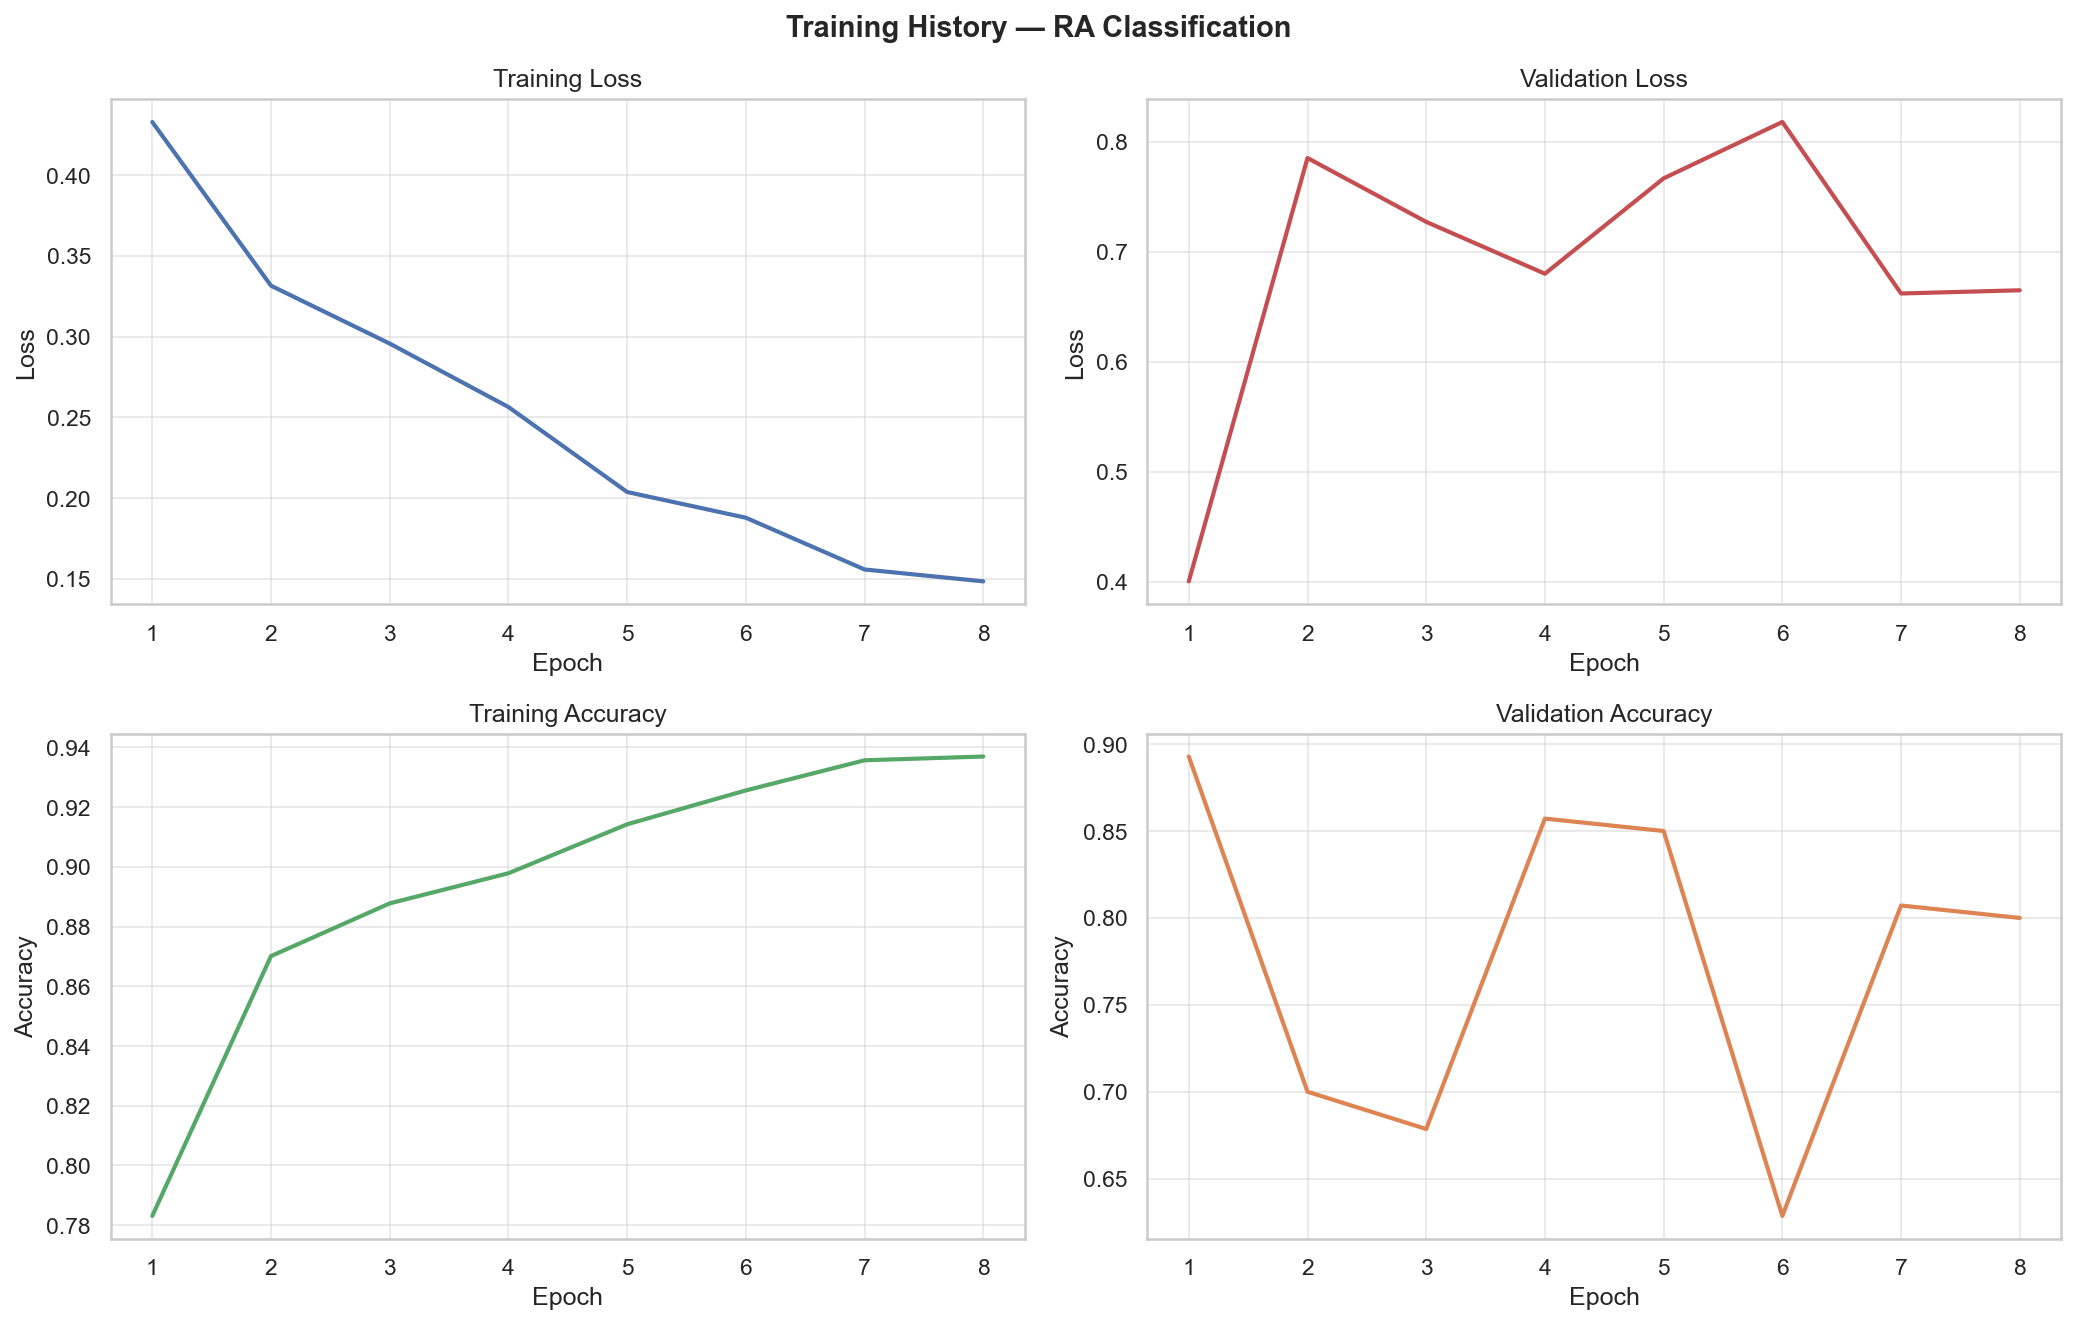

In [20]:
# Display the combined training history inline in the notebook
combined_plot = PLOTS_DIR / 'training_history.png'
if combined_plot.exists():
    from IPython.display import Image as IPImage
    display(IPImage(str(combined_plot)))
else:
    print('Training history plot not yet available. Run full training first.')

---
## Section 17 — Load Best Model for Evaluation

In [21]:
# IMPORTANT: We evaluate the BEST checkpoint, not the model from the
# last training epoch. The last epoch may be slightly overfit.

if BEST_MODEL.exists():
    checkpoint = torch.load(BEST_MODEL, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state'])
    model = model.to(device)
    model.eval()
    print(f'Loaded best model from epoch {checkpoint["epoch"]}')
    print(f'  Best val_loss : {checkpoint["val_loss"]:.4f}')
    print(f'  Best val_acc  : {checkpoint["val_acc"]:.4f}')
else:
    print('No checkpoint found — evaluating the current (untrained/smoke-test) model.')
    print('Metrics below will NOT be meaningful without a properly trained model.')

Loaded best model from epoch 1
  Best val_loss : 0.4002
  Best val_acc  : 0.8929


---
## Section 18 — Test Evaluation

We now evaluate the best model on the **held-out test set**.  
The test set is used exactly ONCE here — at the end of the full pipeline.

In [22]:
from src.evaluate import get_predictions, compute_metrics, print_metrics

# Run inference on the full test set
print('Running test-set inference...')
test_labels, test_preds, test_probs = get_predictions(
    model, test_loader, device, CONFIG['mode']
)

print(f'Test samples  : {len(test_labels)}')
print(f'Non-RA actual : {(test_labels == 0).sum()}')
print(f'RA actual     : {(test_labels == 1).sum()}')
print(f'Non-RA pred   : {(test_preds  == 0).sum()}')
print(f'RA pred       : {(test_preds  == 1).sum()}')

Running test-set inference...
Test samples  : 267
Non-RA actual : 2
RA actual     : 265
Non-RA pred   : 41
RA pred       : 226


---
## Section 19–22 — Accuracy, Precision, Recall, F1

In [23]:
# Compute all metrics from actual predictions
test_metrics = compute_metrics(test_labels, test_preds, test_probs)
print_metrics(test_labels, test_preds, test_metrics)


TEST SET EVALUATION RESULTS
  Samples : 267  (Non-RA: 2, RA: 265)

  Accuracy          : 0.8464
  ROC-AUC           : 0.8698

  Per-class metrics:
    Non-RA  Prec=0.0244  Rec=0.5000  F1=0.0465
    RA      Prec=0.9956  Rec=0.8491  F1=0.9165

  Macro avg   F1=0.4815  Prec=0.5100  Rec=0.6745
  Weighted avg F1=0.9100  Prec=0.9883  Rec=0.8464

  Full sklearn classification report:
              precision    recall  f1-score   support

      Non-RA       0.02      0.50      0.05         2
          RA       1.00      0.85      0.92       265

    accuracy                           0.85       267
   macro avg       0.51      0.67      0.48       267
weighted avg       0.99      0.85      0.91       267



---
## Section 23 — ROC-AUC

In [24]:
print(f'ROC-AUC score: {test_metrics["roc_auc"]:.4f}')
print()
print('Interpretation:')
print('  0.5 = random guessing')
print('  1.0 = perfect discrimination')
print('  A value > 0.7 is generally considered acceptable for a clinical task.')
print('  Given the class imbalance, ROC-AUC is a more informative metric than accuracy.')

ROC-AUC score: 0.8698

Interpretation:
  0.5 = random guessing
  1.0 = perfect discrimination
  A value > 0.7 is generally considered acceptable for a clinical task.
  Given the class imbalance, ROC-AUC is a more informative metric than accuracy.


---
## Section 24 — Confusion Matrix

[evaluate] Confusion matrix saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\confusion_matrix.png


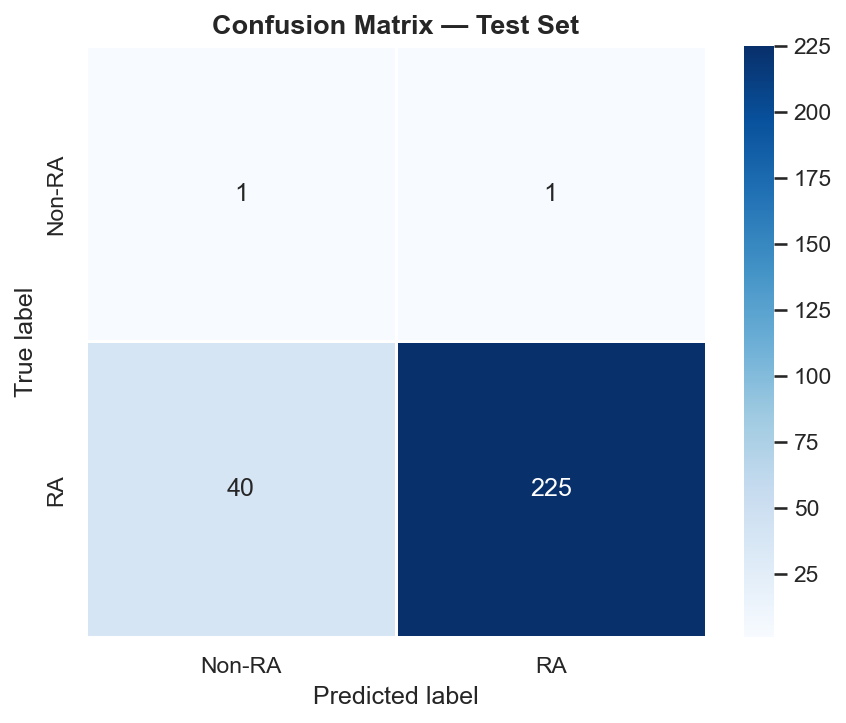

In [25]:
from src.evaluate import plot_confusion_matrix

plot_confusion_matrix(test_labels, test_preds)

# Display inline
cm_path = PLOTS_DIR / 'confusion_matrix.png'
if cm_path.exists():
    from IPython.display import Image as IPImage
    display(IPImage(str(cm_path)))

---
## Section 25 — ROC Curve

[evaluate] ROC curve saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\roc_curve.png


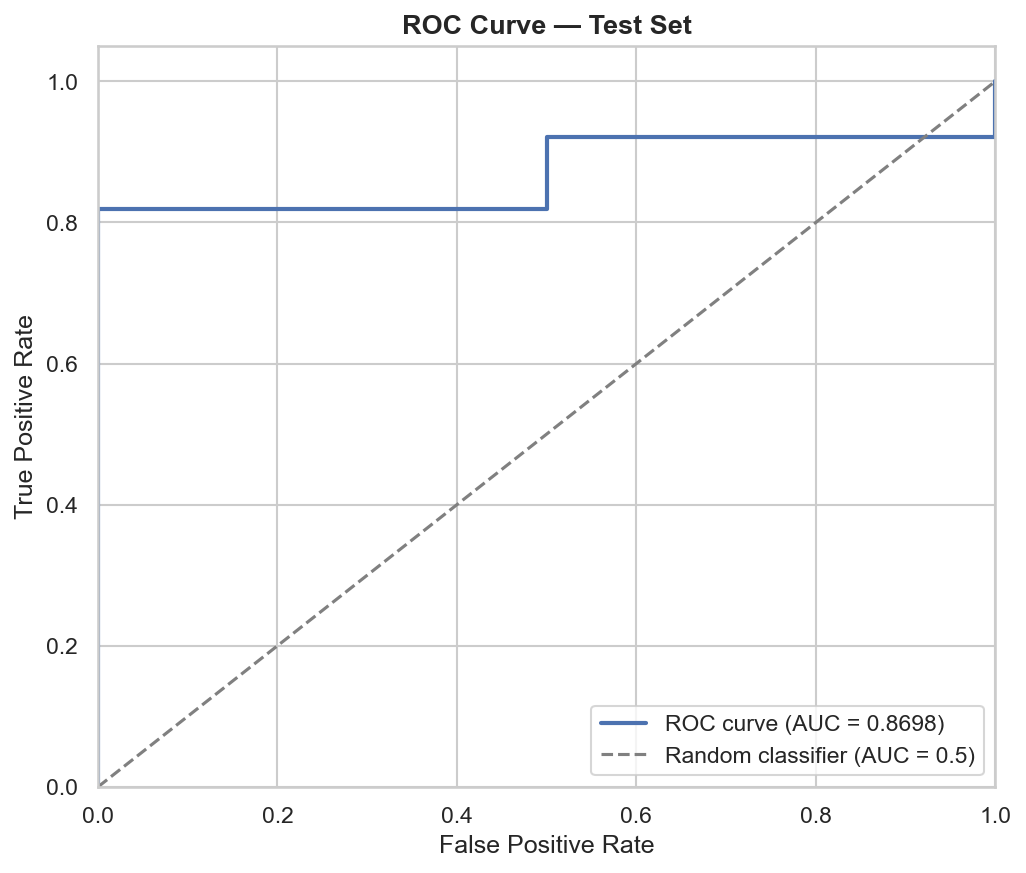

In [26]:
from src.evaluate import plot_roc_curve

plot_roc_curve(test_labels, test_probs)

# Display inline
roc_path = PLOTS_DIR / 'roc_curve.png'
if roc_path.exists():
    from IPython.display import Image as IPImage
    display(IPImage(str(roc_path)))

---
## Section 26 — Save Final Results

In [27]:
from src.evaluate import save_metrics

save_metrics(test_metrics)

print()
print('=== All outputs from this notebook ===')
output_files = [
    BEST_MODEL,
    REPORTS_DIR / 'training_history.csv',
    REPORTS_DIR / 'test_metrics.csv',
    PLOTS_DIR   / 'training_loss.png',
    PLOTS_DIR   / 'validation_loss.png',
    PLOTS_DIR   / 'training_accuracy.png',
    PLOTS_DIR   / 'validation_accuracy.png',
    PLOTS_DIR   / 'training_history.png',
    PLOTS_DIR   / 'confusion_matrix.png',
    PLOTS_DIR   / 'roc_curve.png',
]
for f in output_files:
    status = 'OK     ' if f.exists() else 'MISSING'
    print(f'  [{status}]  {f.name}')

[evaluate] Test metrics saved → C:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\test_metrics.csv

=== All outputs from this notebook ===
  [OK     ]  ra_resnet18_best.pth
  [OK     ]  training_history.csv
  [OK     ]  test_metrics.csv
  [OK     ]  training_loss.png
  [OK     ]  validation_loss.png
  [OK     ]  training_accuracy.png
  [OK     ]  validation_accuracy.png
  [OK     ]  training_history.png
  [OK     ]  confusion_matrix.png
  [OK     ]  roc_curve.png


---
## OPTIONAL — Patient-Stratified Re-split

The dataset inspection found **17 patients** that appear in more than one split.  
The original authors' split is preserved above for reproducibility.  

For rigorous academic evaluation, the cell below shows how to create a strict patient-stratified split using `GroupShuffleSplit`.  

**This cell is NOT run by default.** Uncomment and run it only if you want a leakage-free re-split.

In [28]:
# ── OPTIONAL: Patient-stratified re-split ─────────────────────────────────────
# Uncomment the code below to generate a new split with strict patient isolation.

# from sklearn.model_selection import GroupShuffleSplit
# import pandas as pd
#
# # Load the full manifest
# full_df = pd.read_csv(REPORTS_DIR / 'image_manifest.csv')
#
# patient_ids = full_df['Normalized PatientID'].values
# labels_all  = full_df['isRA'].values
#
# # Split: 80% train+val, 20% test — no patient can span the boundary
# gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
# trainval_idx, test_idx = next(gss_test.split(full_df, labels_all, groups=patient_ids))
#
# trainval_df = full_df.iloc[trainval_idx].reset_index(drop=True)
# new_test_df = full_df.iloc[test_idx].reset_index(drop=True)
#
# # Split trainval into train (75%) and val (25%)
# gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
# tv_pids = trainval_df['Normalized PatientID'].values
# train_idx2, val_idx2 = next(gss_val.split(trainval_df, trainval_df['isRA'], groups=tv_pids))
#
# new_train_df = trainval_df.iloc[train_idx2]
# new_val_df   = trainval_df.iloc[val_idx2]
#
# print(f'New train: {len(new_train_df)}, val: {len(new_val_df)}, test: {len(new_test_df)}')
#
# # Verify NO patient overlap
# check_patient_leakage(new_train_df, new_val_df, new_test_df)
#
# # Save (optional — overwrites original manifests, so be careful)
# # new_train_df.to_csv(REPORTS_DIR / 'train_manifest_stratified.csv', index=False)
# # new_val_df.to_csv(  REPORTS_DIR / 'val_manifest_stratified.csv',   index=False)
# # new_test_df.to_csv( REPORTS_DIR / 'test_manifest_stratified.csv',  index=False)

print('Optional re-split cell is commented out (not run).')
print('Uncomment the code above to generate a patient-stratified split.')

Optional re-split cell is commented out (not run).
Uncomment the code above to generate a patient-stratified split.
